## Common solution - seperation of variables
$$ \frac{dy}{dx} = xy^2 + x $$
$$ \frac{dy}{dx} = x(y^2 + 1) $$
$$ \frac{1}{y^2 + 1}dy = xdx $$
$$ \int\frac{1}{y^2 + 1}dy = \int xdx $$
$$ \arctan(y) + C_2 = \frac{x^2}{2} + C_1 $$
$$ y = f(x) = \tan{(\frac{x^2}{2} + C)} $$
Given $f(-1) = 1$:
$$ \tan{(\frac{(-1)^2}{2}+C)} = 1 $$
$$ \frac{1}{2} + C = \frac{\pi}{4} $$
$$ C = \frac{\pi - 2}{4} $$
So the full solution is:
$$ f(x) = \tan{(\frac{x^2}{2} + \frac{\pi - 2}{4})} $$
$$ y = f(x) = \tan{(\frac{2x^2 + \pi - 2}{4})} $$

## Numerical solution - Symmetrical Euler method (Trapezoid rule)
$$
y' = f(x, y) = x y^2 + x
$$

$$
U^{n+1} = U^n + \frac{\tau}{2} \left( f(t_n, U^n) + f(t_{n+1}, U^{n+1}) \right)
$$

$$
U^{n+1} = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} (U^{n+1})^2 + t_{n+1} \right)
$$

$$
U^{n+1} - \frac{\tau}{2} t_{n+1} (U^{n+1})^2 = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right)
$$

$$
U^{n+1} - \frac{\tau}{2} t_{n+1} (U^{n+1})^2 = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right)
$$

$$
u(x) = x - \frac{\tau}{2} t_{n+1} (x)^2 - \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right) = 0
$$

Solving for $x$ using non-linear equation methods will yield $U^{n+1}$. Here: start value - $U^{(0)}$, steps in the domain - $t_n$, the step size - $\tau$, are known:
$$
u(x) = 0, x = U^{n+1}
$$

Using simple iterations, finding $g(x) = x$:
$$
u(x) = 0 \rightarrow x - \frac{\tau}{2} t_{n+1} (x)^2 - \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right) = 0
$$

$$
g(x) = x = \frac{\tau}{2} t_{n+1} (x)^2 + \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right)
$$

So that iteration $x_{i+1} = g(x_i)$ reaches $g(x_i) = x_i + \epsilon$ with some error $\epsilon$ when $|g(x_i) - x_i| \leq \frac{1-q}{q}\epsilon$, where $q = |g'(x_i)| = |\tau x_i t_{n+1}| < 1$ \
And because $max(|\tau x_i t_{n+1}|) \rightarrow +\infty < 1$ is not true, the process converges
.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
class SimpleIterationsSolver:
  def setup(self, g, g_, x0, min_error=1e-5):
    self.g = g
    self.g_ = g_
    self.x0 = x0
    self.min_error = min_error
    return self

  def _f_error(self, x):
    return abs(self.g(x) - x)

  def _f_min_error_bound(self, x):
    return (1 - self.g_(x)) / self.g_(x) * self.min_error

  def _min_error_reached(self, x_i, error):
    return error <= self._f_min_error_bound(x_i, self.min_error)

  def solve(self):
    i = 0
    x_i = self.x0
    min_error_bound = self._f_min_error_bound(x_i)
    error = self._f_error(x_i)
    while not self._min_error_reached(x_i, error):
      x_i = self.g(x_i)
      min_error_bound = self._f_min_error_bound(x_i)
      error = self._f_error(x_i)
      i += 1
    return x_i

In [2]:
from scipy.optimize import fsolve
import warnings

class IterationsSolver:
  def setup(self, f, x0):
    self.f = f
    self.x0 = x0
    return self
  
  def solve(self):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore", category=RuntimeWarning)
      roots = fsolve(self.f, self.x0)
    if len(roots) > 1:
      print(f'Multiple roots found {roots}')
      raise ValueError
    return roots[0]

In [3]:
def display_dataframe_with_title(title, data):
  from IPython.display import display, Markdown
  display(Markdown(f"### {title}"))
  display(data)

In [10]:
# Third-Order Runge-Kutta and Symmetric Euler solutions
def solve_ode(step):
  x_interval = [-1, 1.5]
  n = int((x_interval[1] - x_interval[0]) / step)
  ts = np.linspace(x_interval[0], x_interval[1], n)
  Us_runge = np.zeros(n)
  Us_runge[0] = 1
  Us_euler = np.zeros(n)
  Us_euler[0] = Us_runge[0]
  a = [0.5, 1]
  b = [0.5, -1, 2]
  sig = [1/6, 2/3, 1/6]
  f = lambda x, y: x*y*y + x
  # the real solution to y
  g = lambda x: np.tan((2*x*x + np.pi - 2)/4)
  # L1 norm
  f_error = lambda x, y: abs(x - y)
  Us_real = g(ts)
  full_error_runge = 0
  full_error_euler = 0
  df = pd.DataFrame(columns=['iter.i', 't_i', 'U(i+1)_runge', 'U(i+1)_euler',
  'U(i+1)_real', 'L1_error_runge', 'L1_error_euler', 'error_average_runge', 'error_average_euler'])
  for i in range(n-1):
    k1 = f(ts[i], Us_runge[i])
    k2 = f(ts[i] + a[0] * step, Us_runge[i] + b[0] * step * k1)
    k3 = f(ts[i] + a[1] * step, Us_runge[i] + step * (b[1] * k1 + b[2] * k2))
    Us_runge[i+1] = Us_runge[i] + step * (sig[0] * k1 + sig[1] * k2 + sig[2] * k3)
    full_error_runge += f_error(Us_real[i+1], Us_runge[i+1])
    # Us_euler[i+1] = SimpleIterationsSolver()\
    # .setup(
    #   lambda x: step/2 * ts[i+1] * x*x + (Us_euler[i] + step/2 * (ts[i] * Us_euler[i] * Us_euler[i] + ts[i] + ts[i+1])),
    #   lambda x: step * x * ts[i+1],
    #   x0=0
    # ).solve()
    Us_euler[i+1] = IterationsSolver()\
    .setup(
      lambda x: x - step/2 * ts[i+1] * x*x - (Us_euler[i] + step/2 * (ts[i] * Us_euler[i] * Us_euler[i] + ts[i] + ts[i+1])),
      x0=0
    ).solve()
    full_error_euler += f_error(Us_real[i+1], Us_euler[i+1])
    df.loc[i] = [i, ts[i], Us_runge[i+1], Us_euler[i+1], Us_real[i+1],
                 f_error(Us_real[i+1], Us_runge[i+1]), f_error(Us_real[i+1],
                  Us_euler[i+1]), full_error_runge/(i+1), full_error_euler/(i+1)]

  plt.figure()
  plt.plot(ts, Us_real, '-', label='Real values')
  plt.plot(ts, Us_runge, 'o', label='Runge-Kutta 3rd order')
  plt.plot(ts, Us_euler, 'o', label='Euler\'s symmetric')
  plt.title(f'y\' = x*y*y + x, y approximation and real values, step = {step}')
  plt.legend()
  plt.xlabel('x')
  plt.ylabel('y')
  plt.ylim(-20, 20)
  plt.plot()
  display_dataframe_with_title(f'Iteration table, step: {step}', df)
  return (df["error_average_runge"].iloc[-1], df["error_average_euler"].iloc[-1])

### Iteration table, step: 0.5

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000,0.432129,0.391855,0.371514,0.060615,0.020341,0.060615,0.020341
1,1.0,-0.375,0.362285,0.354044,0.327674,0.034612,0.026370,0.047613,0.023355
2,2.0,0.250,0.687741,0.774266,0.789346,0.101605,0.015080,0.065610,0.020597
3,3.0,0.875,2.281751,1.335183,6.180927,3.899176,4.845744,1.024002,1.226884


### Iteration table, step: 0.25

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.636723,0.624512,0.607890,0.028834,0.016623,0.028834,0.016623
1,1.0,-0.722222,0.444141,0.433051,0.404249,0.039892,0.028802,0.034363,0.022712
2,2.0,-0.444444,0.351772,0.343781,0.308555,0.043217,0.035226,0.037314,0.026884
3,3.0,-0.166667,0.340237,0.335942,0.300124,0.040113,0.035818,0.038014,0.029117
4,4.0,0.111111,0.407723,0.408106,0.377563,0.030161,0.030543,0.036443,0.029402
5,5.0,0.388889,0.567161,0.575773,0.556239,0.010922,0.019534,0.032190,0.027758
6,6.0,0.666667,0.867171,0.900524,0.897416,0.030246,0.003108,0.031912,0.024236
7,7.0,0.944444,1.497930,1.718044,1.674000,0.176070,0.044044,0.049932,0.026712
8,8.0,1.222222,3.754063,2.666715,6.180927,2.426864,3.514213,0.314035,0.414212


### Iteration table, step: 0.125

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.789419,0.787098,0.780080,0.009339,0.007019,0.009339,0.007019
1,1.0,-0.868421,0.637522,0.634598,0.622593,0.014929,0.012005,0.012134,0.009512
2,2.0,-0.736842,0.524794,0.521868,0.506168,0.018626,0.015699,0.014298,0.011574
3,3.0,-0.605263,0.441135,0.438440,0.419951,0.021184,0.018489,0.016020,0.013303
4,4.0,-0.473684,0.381058,0.378696,0.358149,0.022909,0.020546,0.017397,0.014752
5,5.0,-0.342105,0.341552,0.339573,0.317638,0.023914,0.021935,0.018483,0.015949
6,6.0,-0.210526,0.321025,0.319460,0.296796,0.024229,0.022664,0.019304,0.016908
7,7.0,-0.078947,0.318766,0.317643,0.294913,0.023853,0.022730,0.019873,0.017636
8,8.0,0.052632,0.334702,0.334063,0.311929,0.022773,0.022133,0.020195,0.018136
9,9.0,0.184211,0.369375,0.369289,0.348412,0.020963,0.020877,0.020272,0.018410


### Iteration table, step: 0.0625

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.885694,0.885329,0.883013,0.002681,0.002317,0.002681,0.002317
1,1.0,-0.935897,0.789519,0.788957,0.784812,0.004707,0.004145,0.003694,0.003231
2,2.0,-0.871795,0.707566,0.706902,0.701276,0.006291,0.005627,0.004560,0.004029
3,3.0,-0.807692,0.637111,0.636401,0.629545,0.007566,0.006856,0.005311,0.004736
4,4.0,-0.743590,0.576208,0.575486,0.567593,0.008615,0.007894,0.005972,0.005368
5,5.0,-0.679487,0.523446,0.522734,0.513953,0.009493,0.008782,0.006559,0.005937
6,6.0,-0.615385,0.477788,0.477100,0.467552,0.010236,0.009547,0.007084,0.006452
7,7.0,-0.551282,0.438465,0.437808,0.427599,0.010866,0.010209,0.007557,0.006922
8,8.0,-0.487179,0.404902,0.404284,0.393506,0.011397,0.010778,0.007983,0.007350
9,9.0,-0.423077,0.376673,0.376097,0.364835,0.011838,0.011261,0.008369,0.007742


### Iteration table, step: 0.03125

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.940295,0.940243,0.939573,0.000722,0.000670,0.000722,0.000670
1,1.0,-0.968354,0.885711,0.885621,0.884366,0.001345,0.001255,0.001033,0.000963
2,2.0,-0.936709,0.835610,0.835492,0.833723,0.001888,0.001770,0.001318,0.001232
3,3.0,-0.905063,0.789468,0.789329,0.787103,0.002364,0.002226,0.001580,0.001480
4,4.0,-0.873418,0.746847,0.746693,0.744060,0.002787,0.002634,0.001821,0.001711
...,...,...,...,...,...,...,...,...,...
74,74.0,1.341772,2.754321,2.771332,2.806767,0.052447,0.035435,0.006638,0.005850
75,75.0,1.373418,3.177848,3.205088,3.252339,0.074492,0.047251,0.007531,0.006394
76,76.0,1.405063,3.751733,3.799004,3.862582,0.110849,0.063578,0.008873,0.007137
77,77.0,1.436709,4.576381,4.668403,4.753075,0.176694,0.084672,0.011024,0.008131


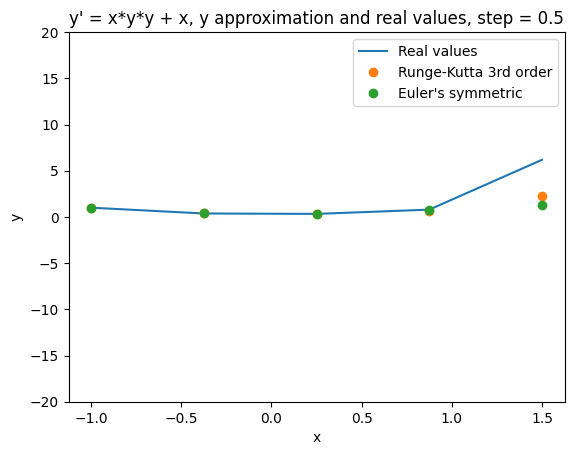

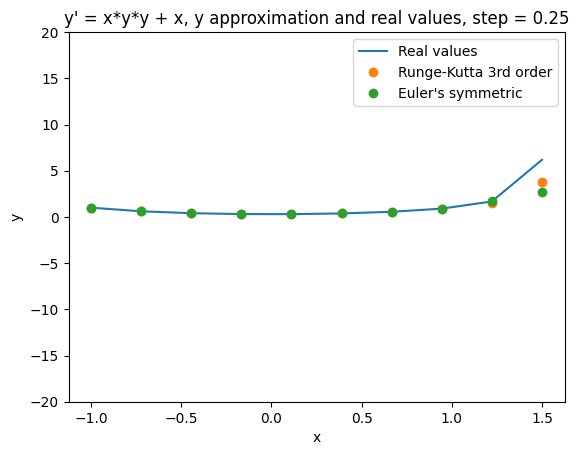

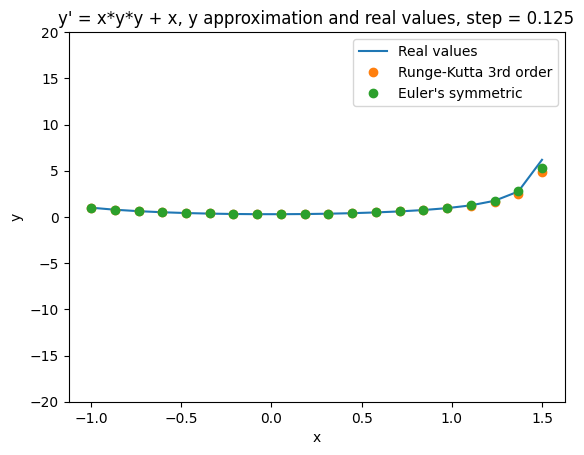

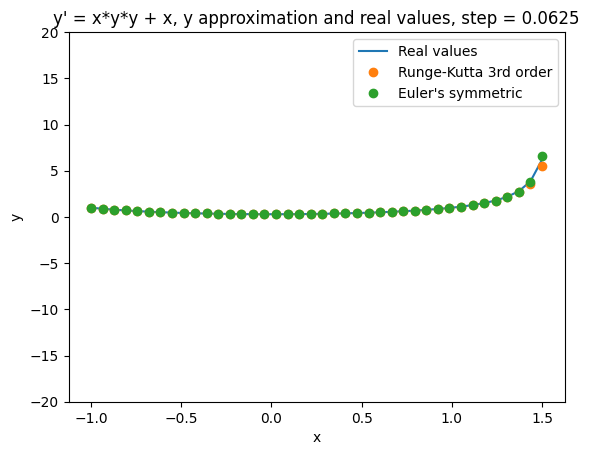

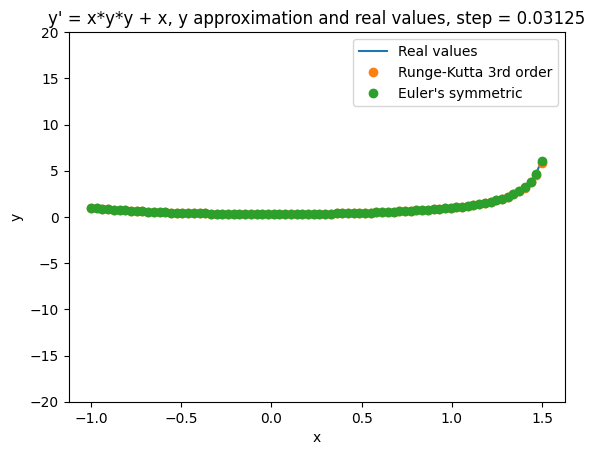

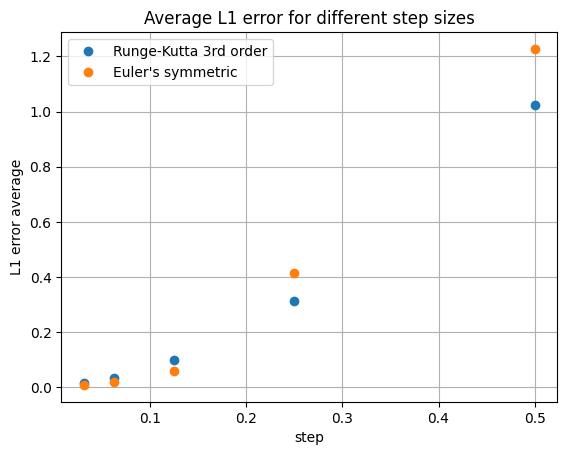

In [11]:
steps = [0.5, 0.25, 0.125, 0.0625, 0.03125]
error_average_eulers = []
error_average_runges = []
for step in steps:
  error_average_runge, error_average_euler = solve_ode(step)
  error_average_eulers.append(error_average_euler)
  error_average_runges.append(error_average_runge)

plt.figure()
plt.plot(steps, error_average_runges, 'o', label='Runge-Kutta 3rd order')
plt.plot(steps, error_average_eulers, 'o', label='Euler\'s symmetric')
plt.title('Average L1 error for different step sizes')
plt.xlabel('step')
plt.ylabel('L1 error average')
plt.legend()
plt.grid()
plt.show()